<a href="https://colab.research.google.com/github/rahula2006/tau-phosphorylation-ode-model/blob/main/tau_ode_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 1: Tau Phosphorylation Dynamics — A Systems Biology ODE Model

**What this is:** This ODE model captures the tug‑of‑war between Tau kinases and phosphatases. While the Vmax/Km values are illustrative placeholders, the directional results are robust: loss of PP2A and PIN1 drives Tau hyperphosphorylation more strongly than kinase hyperactivity alone. Module 1b demonstrates how omics‑derived fold‑changes can scale these parameters, turning a qualitative scaffold into a data‑grounded predictive model.

### The biology
- 4 kinases ADD phosphate to tau: **GSK3B, CDK5, CSNK2A1, AKT1**
- 1 phosphatase REMOVES it: **PP2A** (gene *PPP2CA*)
- **PIN1** facilitates PP2A's action

### Equations
State variable: `Tp` = phosphorylated tau fraction (0–1). `Tu = T_TOTAL − Tp`.

```
R_phos(Tu)   = Σ_k  Vmax_k · Tu / (Km_k + Tu)              [sum over 4 kinases]
f_PIN1       = PIN1_activity / (PIN1_activity + K_pin1)
R_dephos(Tp) = Vmax_PP2A · f_PIN1 · Tp / (Km_PP2A + Tp)

dTp/dt = R_phos(Tu) − R_dephos(Tp)
```

### Honest caveat
Vmax/Km values are **illustrative**, not extracted from kinetic assays — this is a
qualitative proof-of-concept model. The *direction* of results is the finding, not
the exact numbers. See Module 1b at the bottom for how to make this data-grounded
using your own GEO expression data.


## 1. Imports

In [17]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt


## 2. Parameters
Edit these to explore / refine the model.

In [18]:
T_TOTAL = 1.0  # normalized total tau pool

KINASES = {
    "GSK3B":   dict(Vmax=0.40, Km=0.30),
    "CDK5":    dict(Vmax=0.25, Km=0.35),
    "CSNK2A1": dict(Vmax=0.10, Km=0.40),
    "AKT1":    dict(Vmax=0.08, Km=0.30),
}

PP2A = dict(Vmax=0.90, Km=0.30)
PIN1_K = 0.5


## 3. Rate functions and the ODE itself

In [19]:
def r_phos(Tu, kinases):
    """Total phosphorylation rate: sum of Michaelis-Menten terms over all kinases."""
    return sum(k["Vmax"] * Tu / (k["Km"] + Tu) for k in kinases.values())

def r_dephos(Tp, pp2a_vmax, pin1_activity, pp2a_km=PP2A["Km"], pin1_k=PIN1_K):
    """Dephosphorylation rate: PP2A activity scaled by PIN1 facilitation."""
    f_pin1 = pin1_activity / (pin1_activity + pin1_k)
    return pp2a_vmax * f_pin1 * Tp / (pp2a_km + Tp)

def tau_ode(t, y, kinases, pp2a_vmax, pin1_activity):
    """dTp/dt = phosphorylation - dephosphorylation."""
    Tp = y[0]
    Tu = T_TOTAL - Tp
    dTp = r_phos(Tu, kinases) - r_dephos(Tp, pp2a_vmax, pin1_activity)
    return [dTp]


## 4. Scenarios — healthy vs literature-motivated AD-like perturbations

| Scenario | Change | Why (reference) |
|---|---|---|
| Healthy (baseline) | default params | reference state |
| PP2A reduced 50% | Vmax_PP2A x 0.5 | PP2A activity reduced in AD brain (Gong et al., J Neurochem) |
| PP2A + PIN1 reduced | + PIN1_activity x 0.5 | PIN1 depleted in AD-vulnerable neurons (Lu et al., 1999, *Nature*) |
| GSK3B hyperactive | Vmax_GSK3B x 1.5 | GSK3B hyperactivation hypothesis (Hooper et al., 2008) |


In [20]:
GSK3B_hyper = {**KINASES, "GSK3B": dict(Vmax=KINASES["GSK3B"]["Vmax"] * 1.5,
                                          Km=KINASES["GSK3B"]["Km"])}

SCENARIOS = {
    "Healthy (baseline)":          dict(kinases=KINASES,      pp2a_vmax=PP2A["Vmax"],       pin1_activity=1.0),
    "AD-like: PP2A reduced 50%":   dict(kinases=KINASES,      pp2a_vmax=PP2A["Vmax"] * 0.5, pin1_activity=1.0),
    "AD-like: PP2A+PIN1 reduced":  dict(kinases=KINASES,      pp2a_vmax=PP2A["Vmax"] * 0.5, pin1_activity=0.5),
    "AD-like: GSK3B hyperactive":  dict(kinases=GSK3B_hyper,  pp2a_vmax=PP2A["Vmax"],       pin1_activity=1.0),
}


## 5. Simulate each scenario

In [21]:
t_span = (0, 50)
t_eval = np.linspace(*t_span, 500)
Tp0 = [0.10]  # initial phosphorylated fraction (10%)

results = {}
for name, p in SCENARIOS.items():
    sol = solve_ivp(
        tau_ode, t_span, Tp0, t_eval=t_eval,
        args=(p["kinases"], p["pp2a_vmax"], p["pin1_activity"]),
    )
    results[name] = sol

print("Simulation complete for", len(results), "scenarios.")


Simulation complete for 4 scenarios.


## 6. Plot — time courses

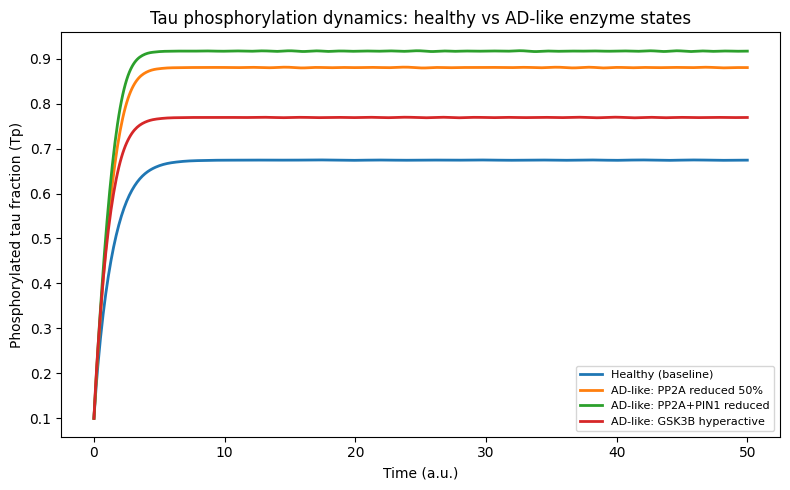

In [22]:
plt.figure(figsize=(8, 5))
for name, sol in results.items():
    plt.plot(sol.t, sol.y[0], label=name, linewidth=2)
plt.xlabel("Time (a.u.)")
plt.ylabel("Phosphorylated tau fraction (Tp)")
plt.title("Tau phosphorylation dynamics: healthy vs AD-like enzyme states")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig("tau_phosphorylation_dynamics.png", dpi=150)
plt.show()


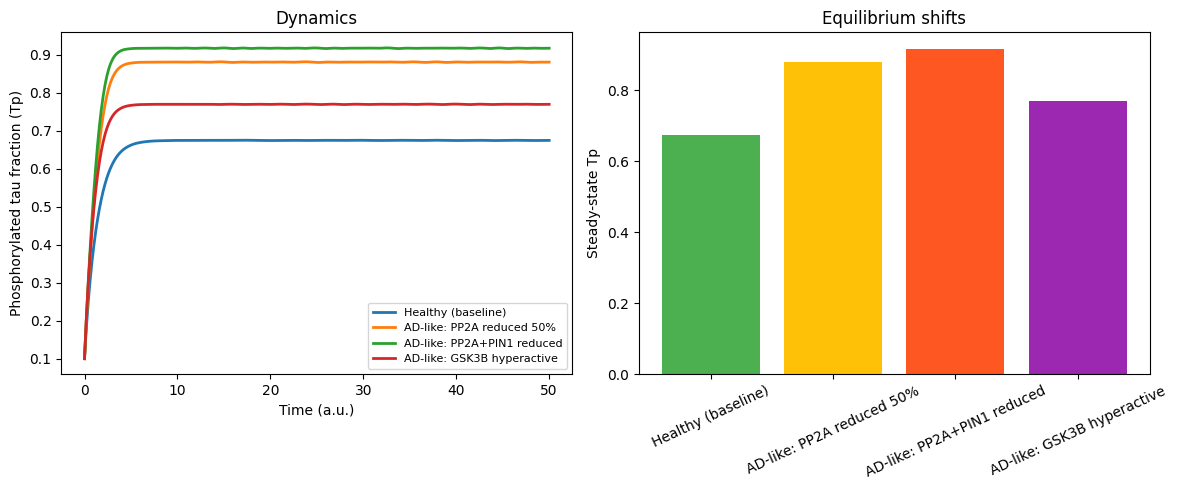

In [24]:
# Overlay + bar chart in one figure
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Left: time courses
for name, sol in results.items():
    axes[0].plot(sol.t, sol.y[0], label=name, linewidth=2)
axes[0].set_xlabel("Time (a.u.)")
axes[0].set_ylabel("Phosphorylated tau fraction (Tp)")
axes[0].set_title("Dynamics")
axes[0].legend(fontsize=8)

# Right: steady-state comparison
steady_states = {name: sol.y[0][-1] for name, sol in results.items()}
axes[1].bar(list(steady_states.keys()), list(steady_states.values()),
            color=["#4CAF50", "#FFC107", "#FF5722", "#9C27B0"])
axes[1].set_ylabel("Steady-state Tp")
axes[1].set_title("Equilibrium shifts")
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.savefig("tau_module1_combined.png", dpi=150)
plt.show()


## 7. Plot — steady-state comparison

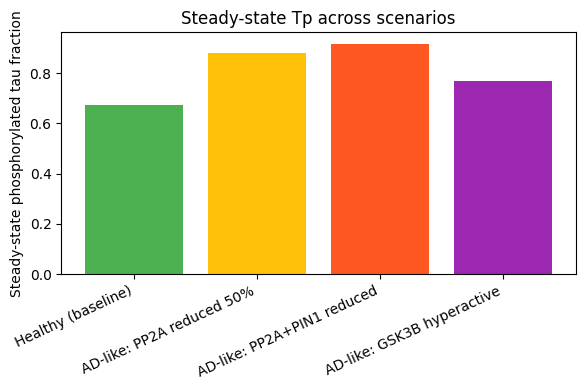

Steady-state phosphorylated tau fractions:
  Healthy (baseline)              : 0.674
  AD-like: PP2A reduced 50%       : 0.880
  AD-like: PP2A+PIN1 reduced      : 0.917
  AD-like: GSK3B hyperactive      : 0.769


In [23]:
steady_states = {name: sol.y[0][-1] for name, sol in results.items()}

plt.figure(figsize=(6, 4))
plt.bar(list(steady_states.keys()), list(steady_states.values()),
        color=["#4CAF50", "#FFC107", "#FF5722", "#9C27B0"])
plt.ylabel("Steady-state phosphorylated tau fraction")
plt.xticks(rotation=25, ha="right")
plt.title("Steady-state Tp across scenarios")
plt.tight_layout()
plt.savefig("tau_steady_state_comparison.png", dpi=150)
plt.show()

print("Steady-state phosphorylated tau fractions:")
for name, val in steady_states.items():
    print(f"  {name:32s}: {val:.3f}")
